In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,CIFAR100


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.ToTensor()
])          


In [3]:
cifar100_train = CIFAR100(root='./data', train=True, download=True, transform=transform)
cifar100_test = CIFAR100(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar100_train)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size -valid_size)

trainset,validset = random_split(images, (train_size, valid_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

40000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_11.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.42023615884780885, 0.8867)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.2882943983078003, 0.6451)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu

apple            0.955000
aquarium_fish    0.974937
baby             0.788114
bear             0.813776
beaver           0.789216
                   ...   
whale            0.883610
willow_tree      0.835411
wolf             0.848329
woman            0.707317
worm             0.846154
Length: 100, dtype: float64

In [15]:
each_f1=2*p*r/(p+r)
each_f1

apple            0.962217
aquarium_fish    0.965261
baby             0.825440
bear             0.809645
beaver           0.781553
                   ...   
whale            0.876325
willow_tree      0.791027
wolf             0.905350
woman            0.758170
worm             0.889179
Length: 100, dtype: float64

In [16]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('TandF')

if(split_mode[0]=='classf1'):
    targetF=[x  for x in each_f1.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
elif(split_mode[0]=='classaccu'):
    targetF=[x  for x in each_accu.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
else:
    split=split_mode

indexF,indexT=split_data(model_0,train_dl,split)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(4532, 35468)

In [17]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split)
len(indexF_v),len(indexT_v)

(3549, 6451)

In [18]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [54]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        model_fc_layer=nn.Linear(model_fc_layer.in_features,2)
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    elif(data_name=='0'):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    else:   
        model_fc_layer=nn.Linear(model_fc_layer.in_features,len(train_dl.dataset.dataset.classes))
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model

Epoch=0,train_loss=0.3087188503205776,train_accu=0.88655
Epoch=0,valid_loss=0.740027874469757,valid_accu=0.6452
0
Epoch=1,train_loss=0.28934924573898313,train_accu=0.886825
Epoch=1,valid_loss=0.8276698086738586,valid_accu=0.6451
Epoch=2,train_loss=0.2809215727627277,train_accu=0.8873
Epoch=2,valid_loss=0.7602690680027008,valid_accu=0.6453
0
Epoch=3,train_loss=0.26630558061003684,train_accu=0.887925
Epoch=3,valid_loss=0.83035202627182,valid_accu=0.6449
Epoch=4,train_loss=0.2586222944021225,train_accu=0.893325
Epoch=4,valid_loss=0.7771060960769653,valid_accu=0.6468
0
Epoch=5,train_loss=0.24400227518081666,train_accu=0.895175
Epoch=5,valid_loss=0.7887613310813903,valid_accu=0.6461
Epoch=6,train_loss=0.23022830914258957,train_accu=0.90285
Epoch=6,valid_loss=0.7702094180107116,valid_accu=0.647
0
Epoch=7,train_loss=0.20945266457796097,train_accu=0.909275
Epoch=7,valid_loss=0.8204724988937377,valid_accu=0.6457
Epoch=8,train_loss=0.19818239517211914,train_accu=0.92135
Epoch=8,valid_loss=0.8145

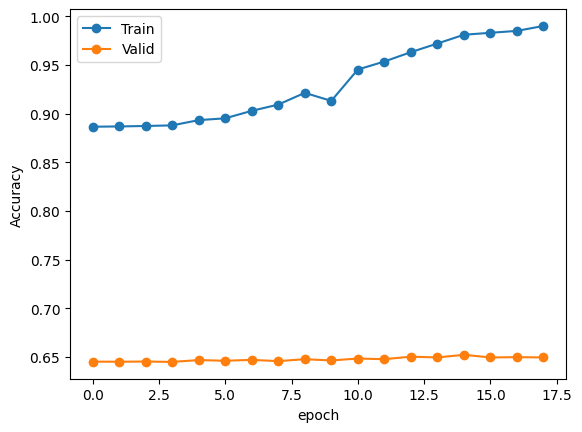

In [20]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# # decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",70,model_0=model_0)

In [21]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=False, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=False, batch_size=batch_size)

Epoch=0,train_loss=0.14584734594423984,train_accu=0.9784594564114131
Epoch=0,valid_loss=0.2216024204864555,valid_accu=0.9445047279491552
0
Epoch=1,train_loss=0.12041629359942824,train_accu=0.983139731589038
Epoch=1,valid_loss=0.20574380345833132,valid_accu=0.9485351108355293
0
Epoch=2,train_loss=0.10393543363023337,train_accu=0.9858182023232209
Epoch=2,valid_loss=0.20486795024952395,valid_accu=0.941404433421175
Epoch=3,train_loss=0.08864430961700845,train_accu=0.989793616781324
Epoch=3,valid_loss=0.18976529260658143,valid_accu=0.9491551697411255
0
Epoch=4,train_loss=0.07449579676330674,train_accu=0.9915980602232999
Epoch=4,valid_loss=0.18409998788147672,valid_accu=0.9432646101379631
Epoch=5,train_loss=0.06260475758229972,train_accu=0.9948686139618811
Epoch=5,valid_loss=0.17700061660333302,valid_accu=0.9521004495427066
0
Epoch=6,train_loss=0.058342499913694196,train_accu=0.9952351415360324
Epoch=6,valid_loss=0.18027378843932387,valid_accu=0.9471399782979383
Epoch=7,train_loss=0.04950909

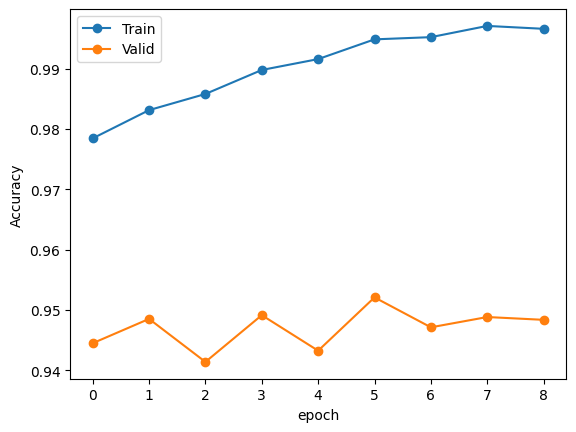

In [22]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.4644435748313238,train_accu=0.5041924095322153
Epoch=0,valid_loss=2.7530532036408064,valid_accu=0.17413355874894337
0
Epoch=1,train_loss=1.326779238754737,train_accu=0.5829655781112092
Epoch=1,valid_loss=2.7126160324980217,valid_accu=0.18117779656241195
0
Epoch=2,train_loss=1.2169423462117759,train_accu=0.6365842894969108
Epoch=2,valid_loss=2.7206573145058366,valid_accu=0.18765849535080303
0
Epoch=3,train_loss=1.0921238995398028,train_accu=0.6992497793468667
Epoch=3,valid_loss=2.725535445631172,valid_accu=0.19413919413919414
0
Epoch=4,train_loss=0.9766512858793994,train_accu=0.7453662842012356
Epoch=4,valid_loss=2.756340715642646,valid_accu=0.19723865877712032
0
Epoch=5,train_loss=0.8761873013764909,train_accu=0.7864077669902912
Epoch=5,valid_loss=2.7571604705320407,valid_accu=0.1952662721893491
Epoch=6,train_loss=0.7848635801465135,train_accu=0.8232568402471315
Epoch=6,valid_loss=2.7870019246034468,valid_accu=0.20484643561566637
0
Epoch=7,train_loss=0.711651557857

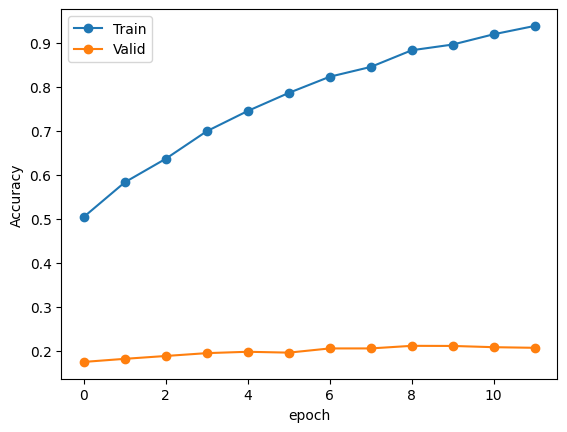

In [23]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [24]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.10676223735064268, 0.981025)

In [25]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.9691402144432067, 0.6522)

In [26]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.06260475718737778, 0.9948686139618811)

In [27]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.6414429395996356, 0.883495145631068)

In [28]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.17700061660333302, 0.9521004495427066)

In [29]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(2.8040537626584103, 0.21076359537897998)

In [30]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.1281872324973345, 0.982225, 4532)

In [31]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(1.1093422474861145, 0.689, 3549)

In [32]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_train_loss,total_train_accu,sum_F,sum_T

(0.16503908883333207, 0.9693, 3911, 36089)

In [33]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.42797753200531, 0.6591, 265, 9735)

In [34]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [35]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = TandF


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.420236,0.886700,1.288294,0.645100
1,Model_Decision,0.106762,0.981025,0.969140,0.652200
2,Model_T,0.062605,0.994869,0.177001,0.952100
3,Model_F,0.641443,0.883495,2.804054,0.210764
4,Total_Model,0.165039,0.969300,1.427978,0.659100
5,Total_Model_with_perfect_decision,0.128187,0.982225,1.109342,0.689000


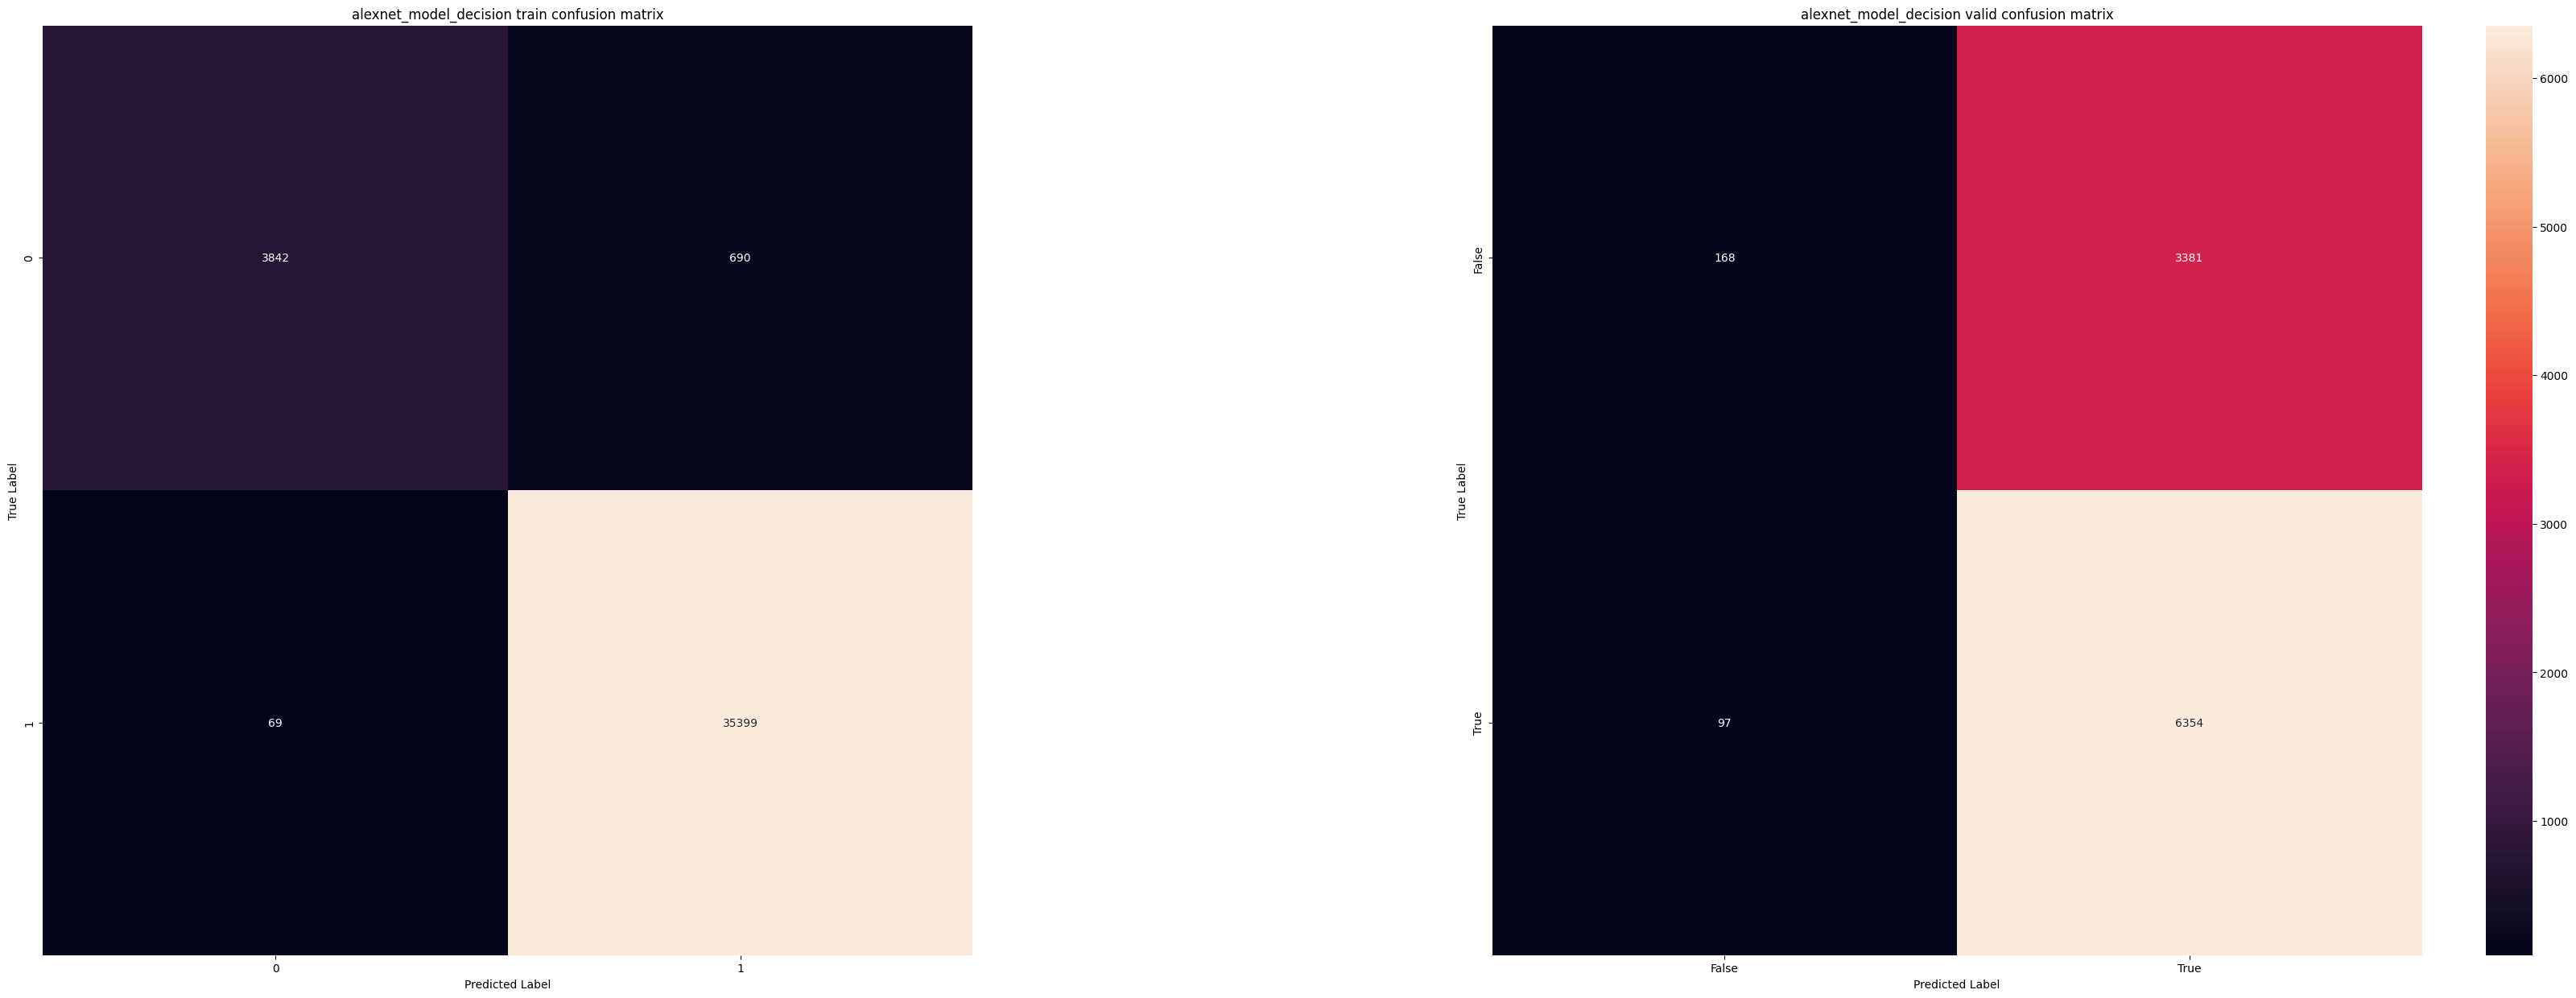

In [36]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

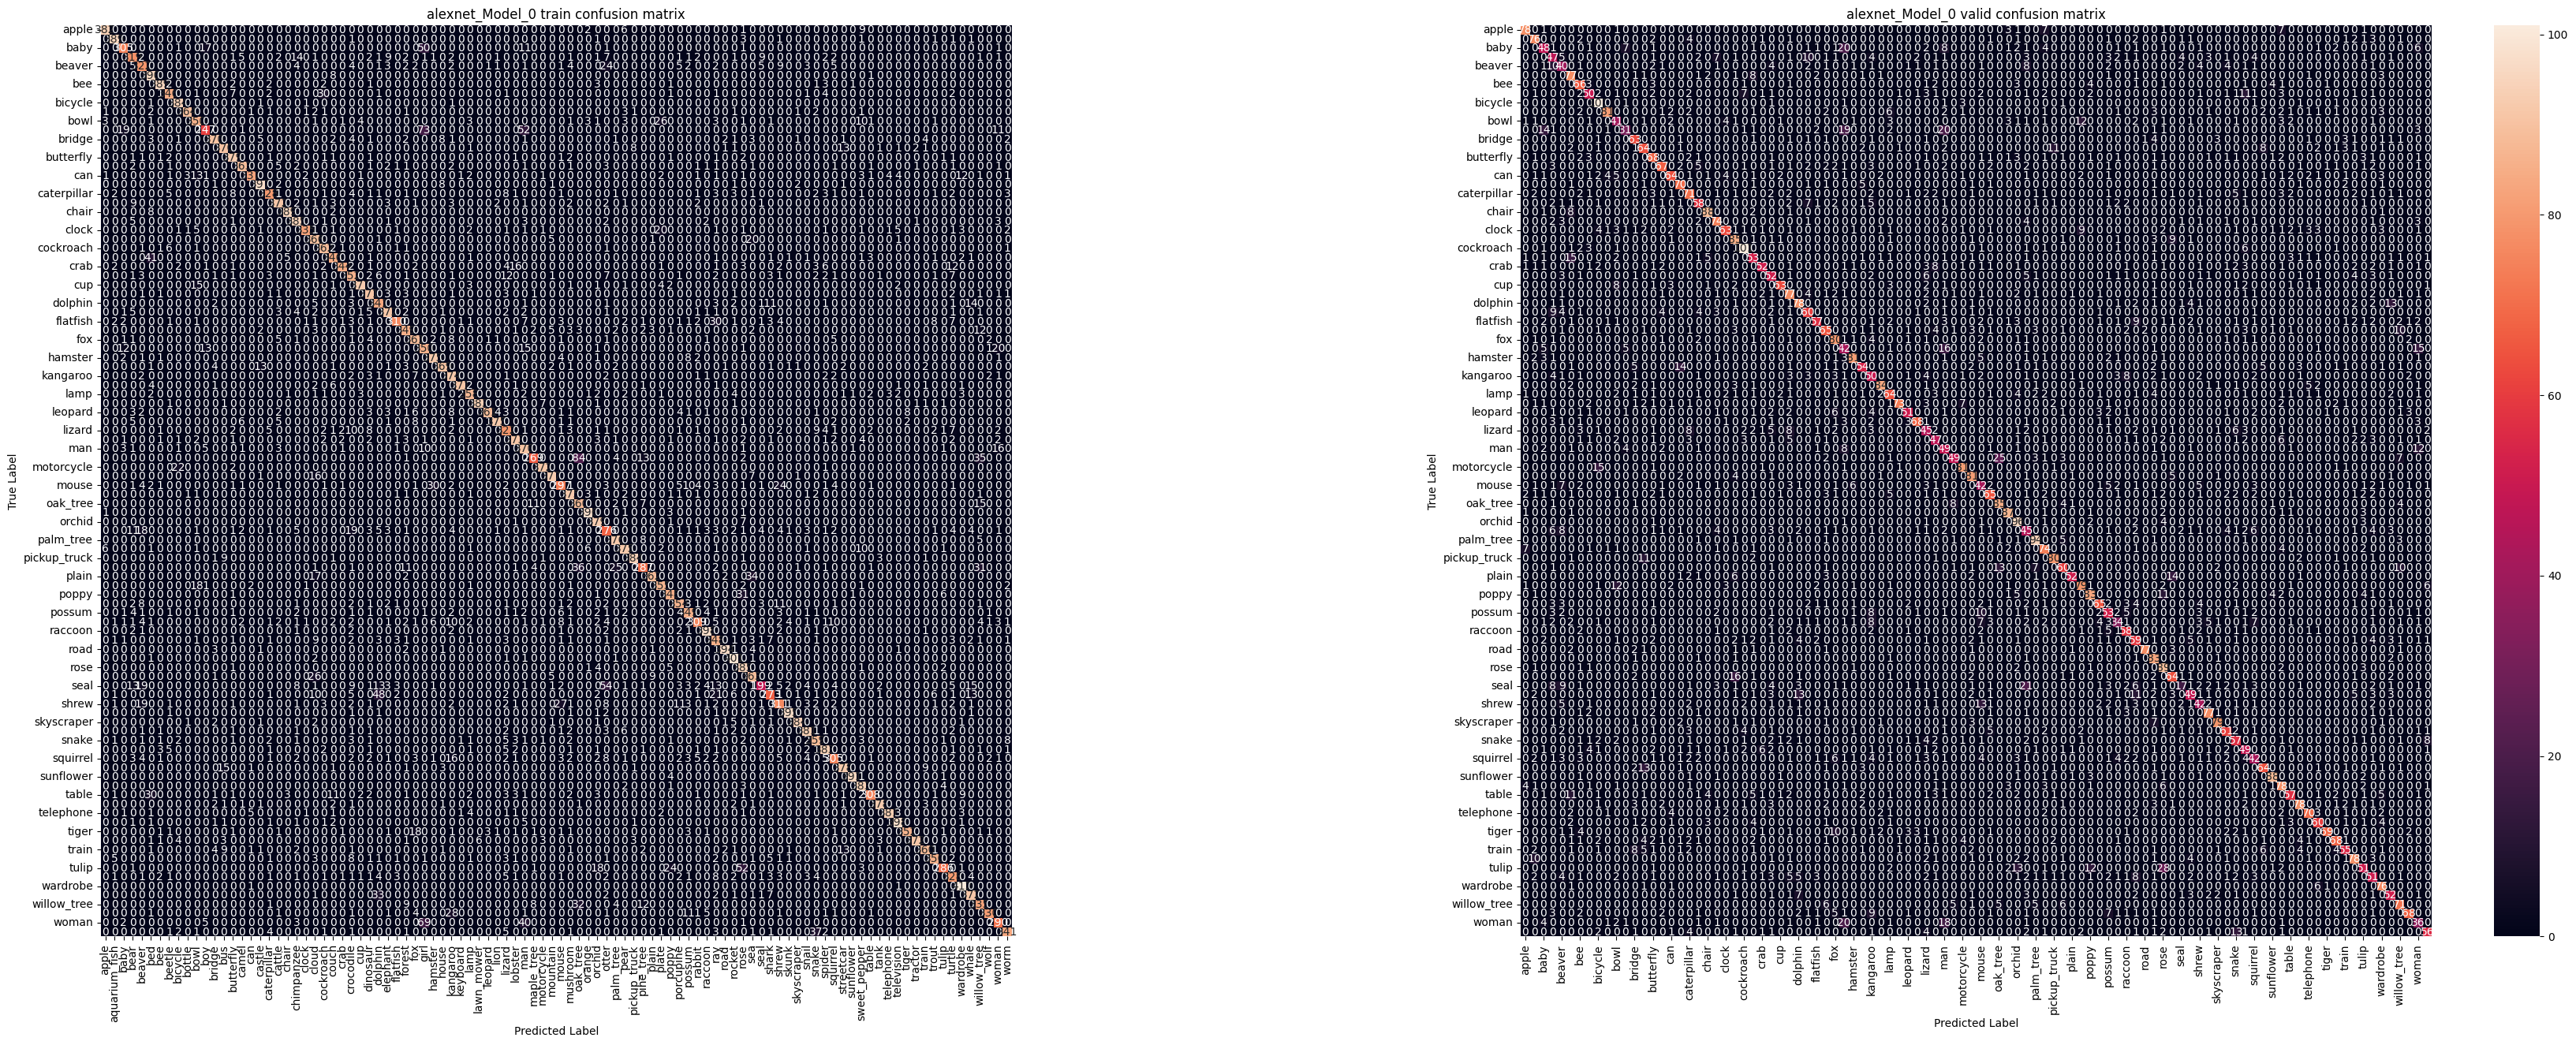

In [37]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

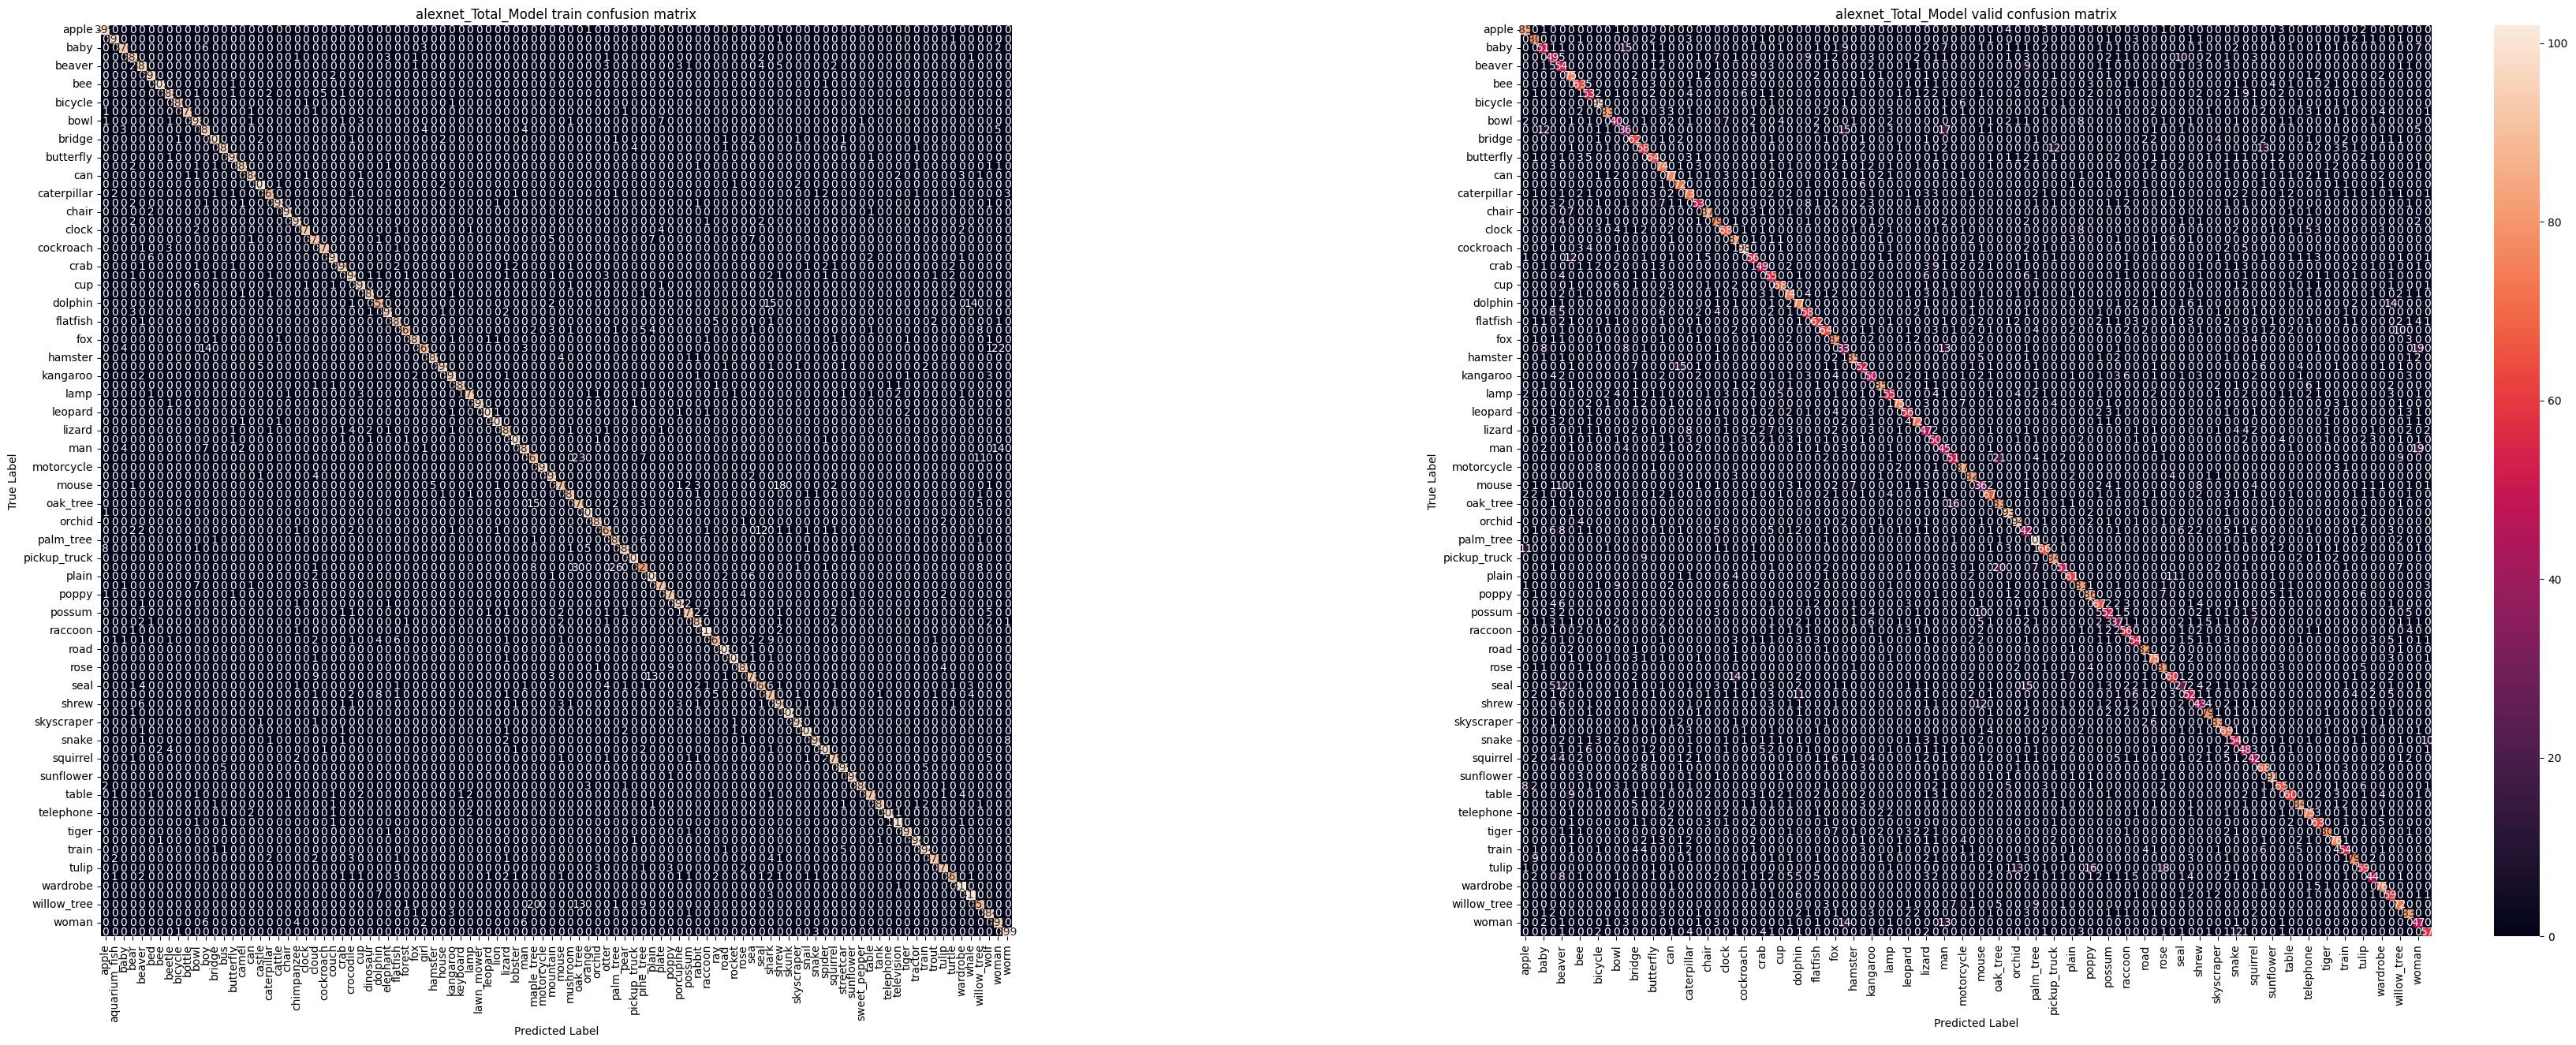

In [38]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

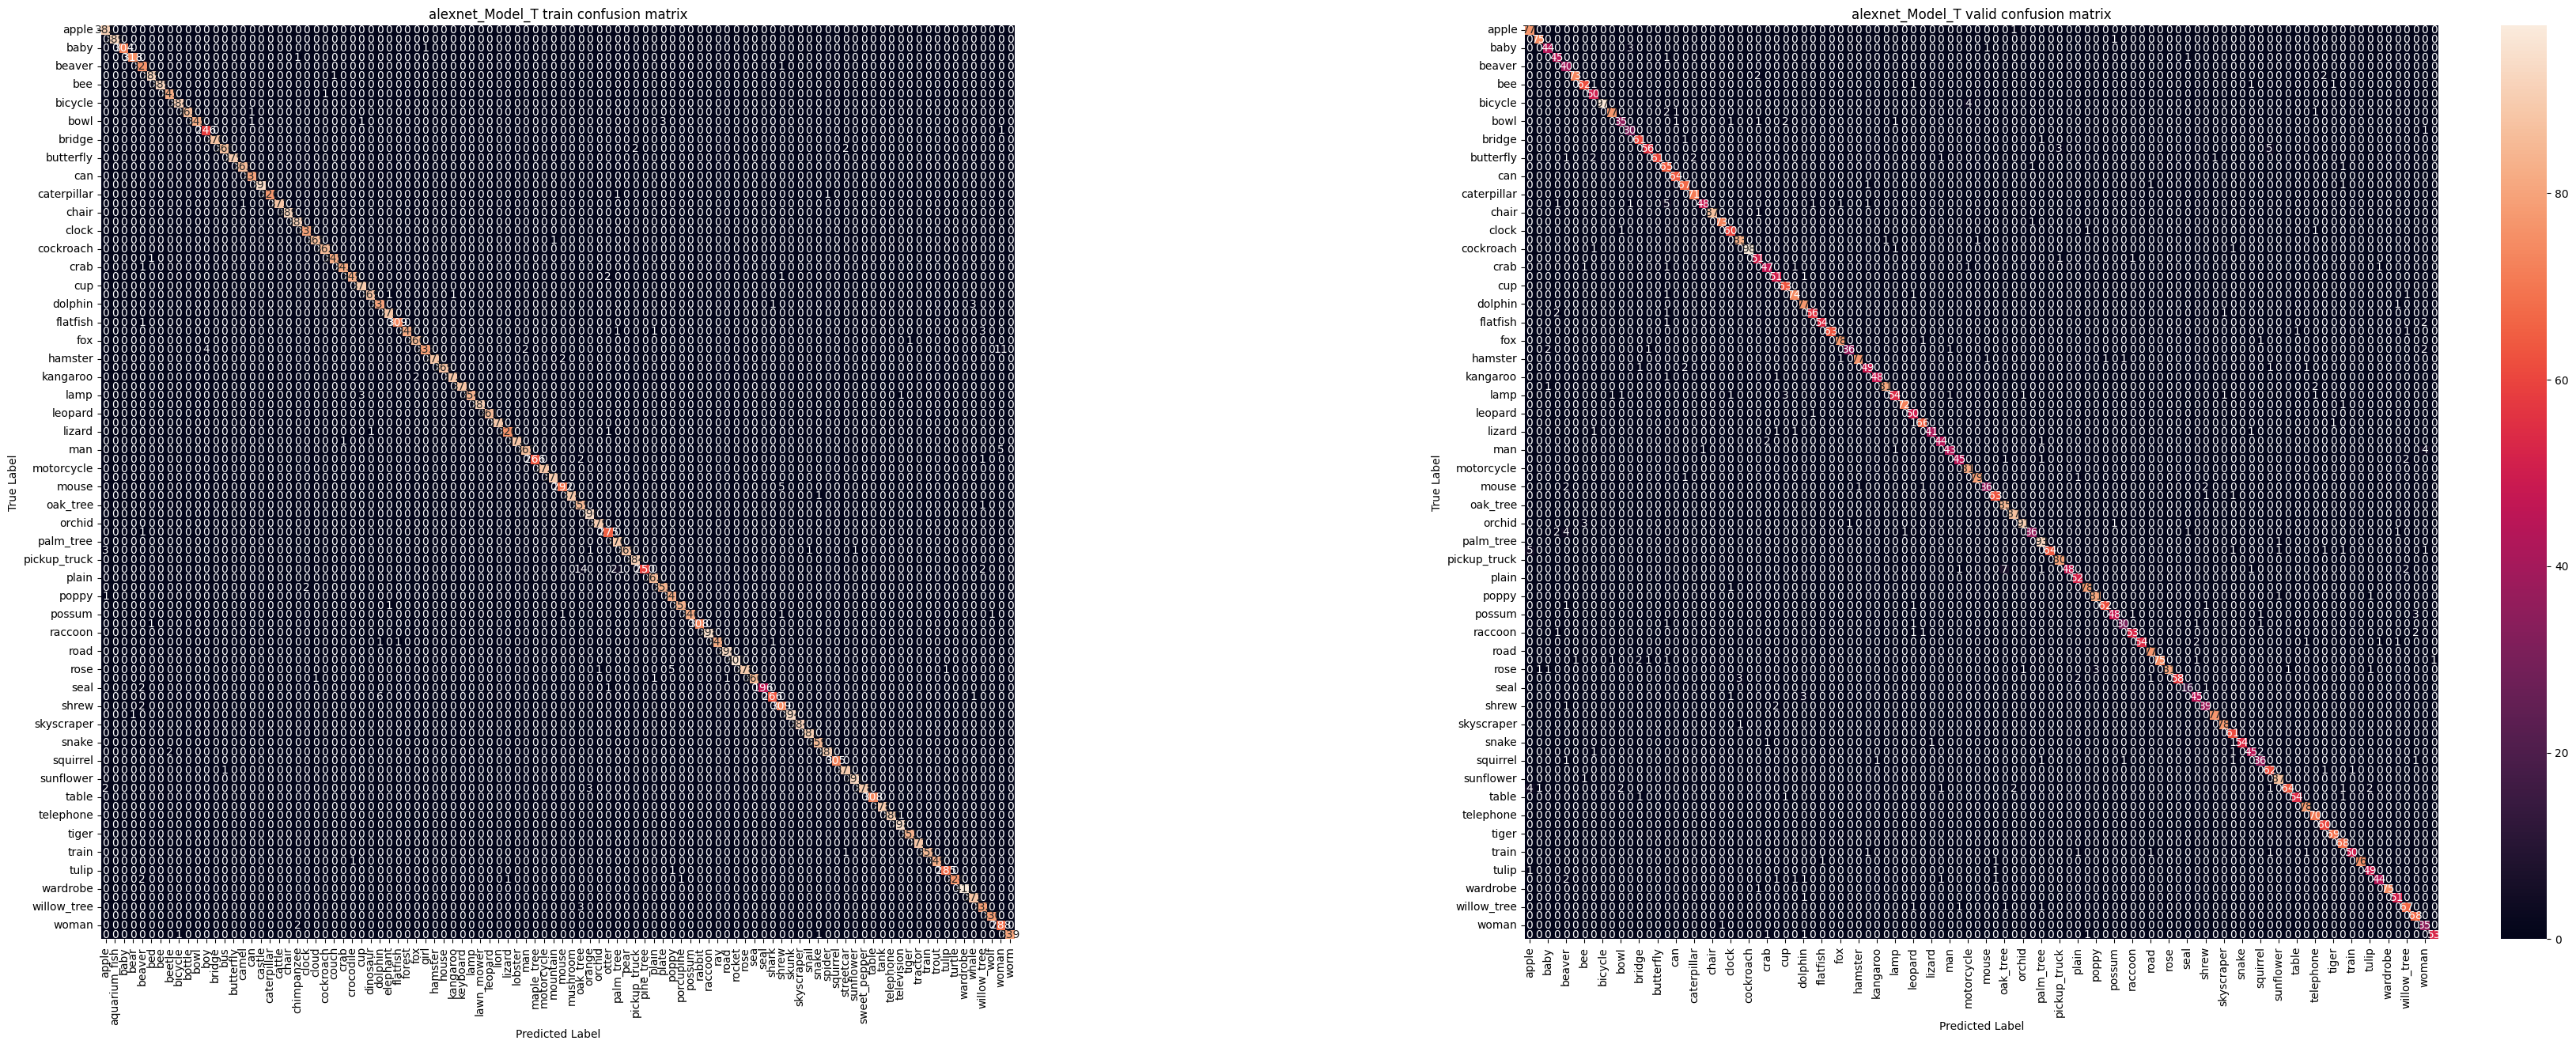

In [39]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

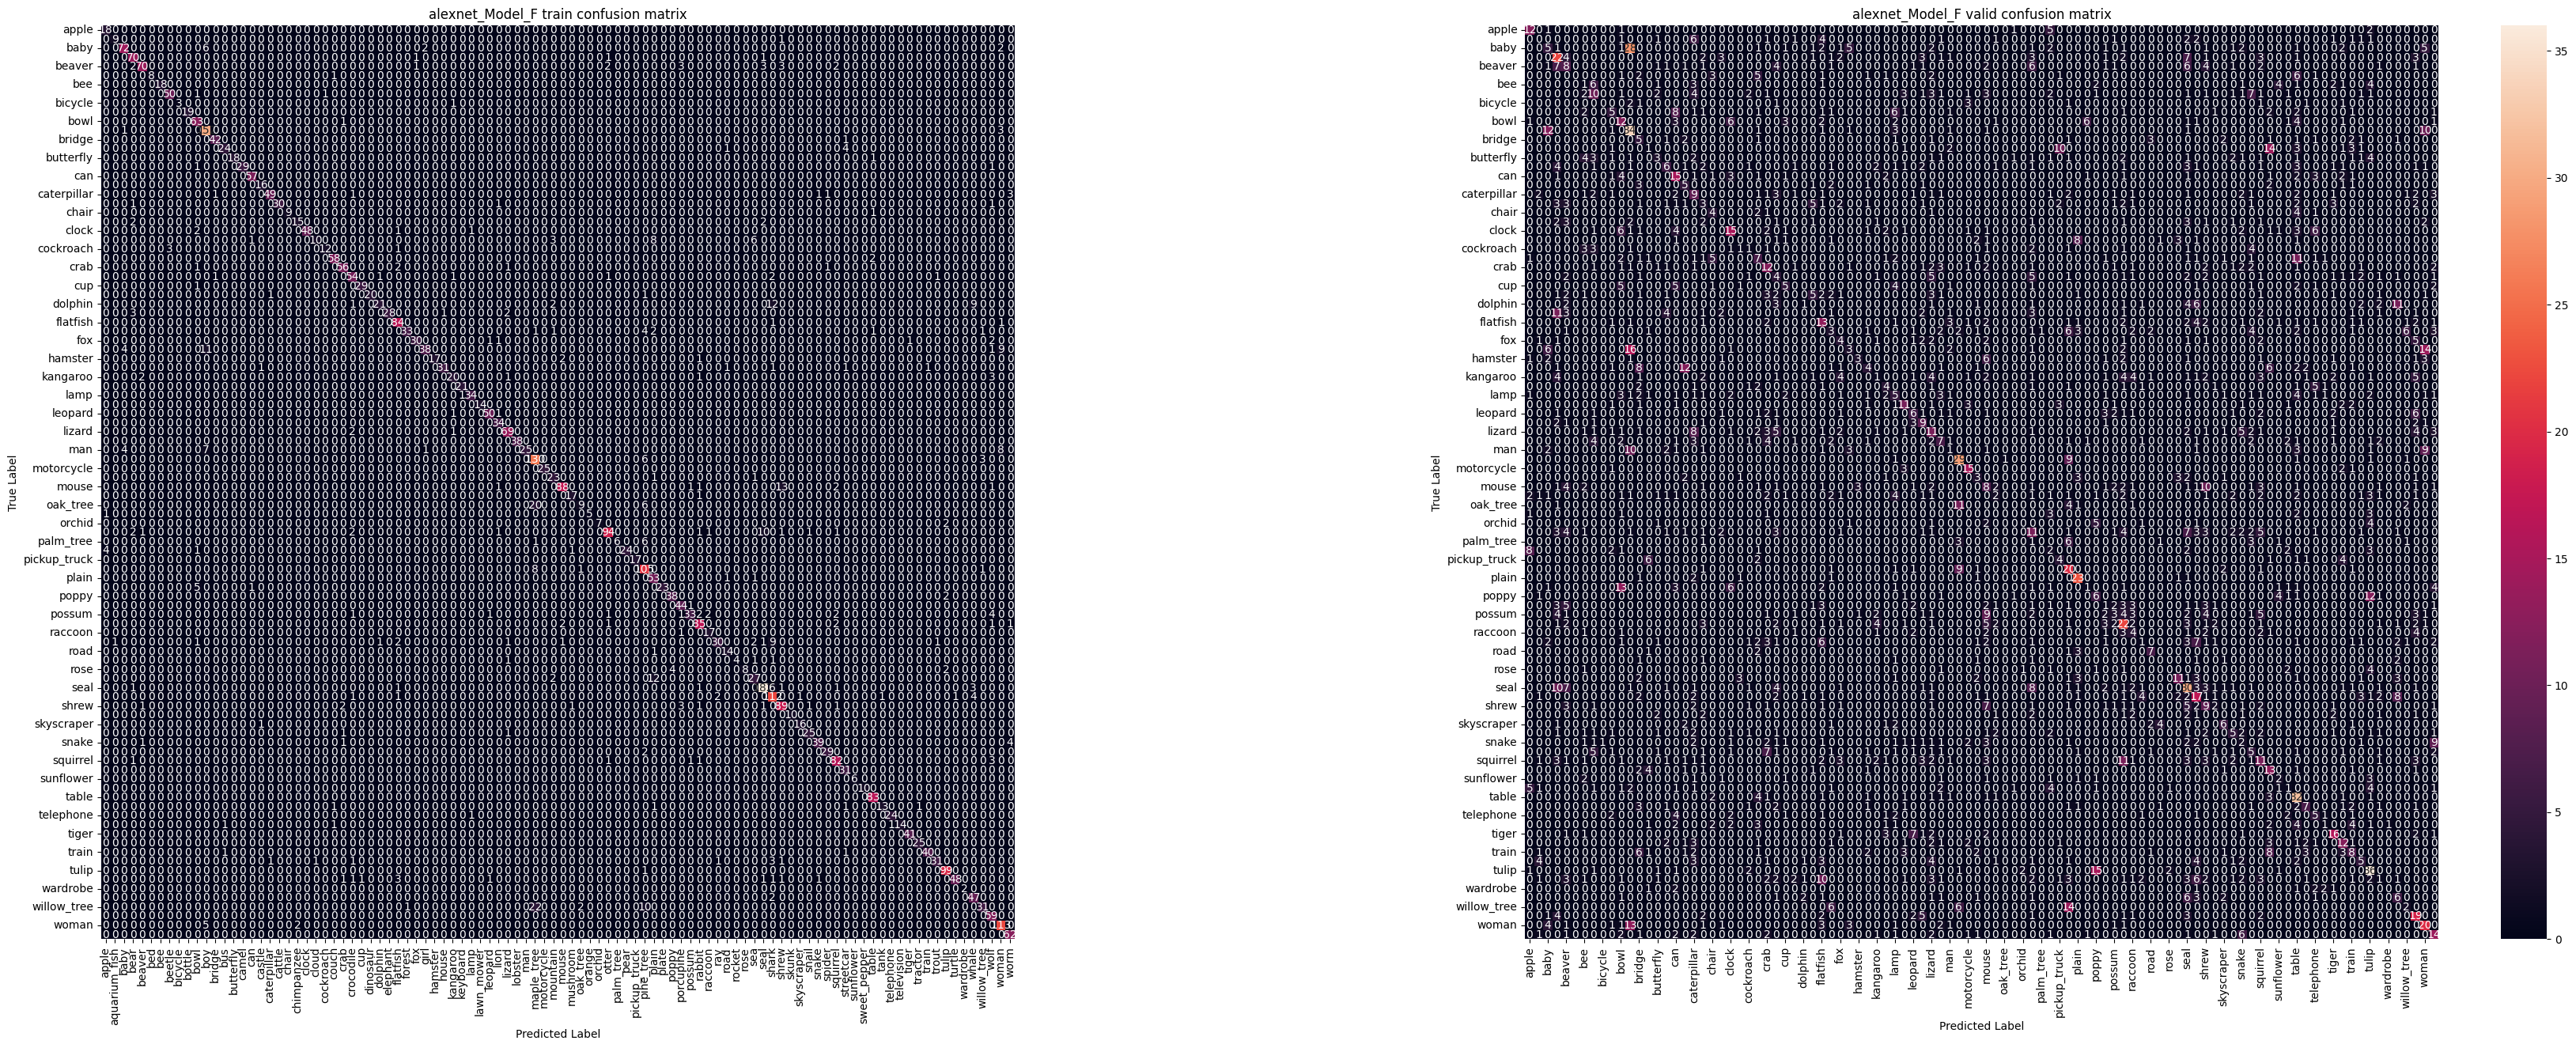

In [40]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [41]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [42]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,45420,40,40,40,40,0.793154,0.724068,0.648189,0.967322,True,True,True,True,True
1,44318,46,98,98,98,0.679335,0.950810,0.682025,0.812522,False,False,False,False,False
2,16821,66,66,66,66,0.898210,0.982264,0.921768,0.998702,True,True,True,True,True
3,22766,2,2,2,2,0.641307,0.791222,0.552182,0.994028,True,True,True,True,True
4,5580,30,73,73,73,0.461028,0.925426,0.692596,0.634998,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,8320,92,92,92,70,0.882414,0.672499,0.521331,0.645297,True,True,False,False,False
39996,13635,40,40,40,40,0.597091,0.988522,0.813944,0.960474,True,True,True,True,True
39997,26595,34,42,34,34,0.437180,0.994970,0.980048,0.996758,False,True,True,True,True
39998,28974,97,97,97,97,0.993684,0.992813,0.889859,0.827926,True,True,True,True,True


In [43]:
len(df_results[df_results['Decision']!=df_results['flag']])

759

In [44]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
5,47219,93,93,64,32,0.249451,0.402268,0.245739,0.516124,True,False,False,True,False
91,43754,10,10,10,10,0.665741,0.988733,0.888311,0.505401,True,True,True,False,True
240,14646,91,91,18,18,0.641768,0.409405,0.444966,0.600872,True,False,False,True,False
336,34166,61,61,10,10,0.748334,0.194743,0.342382,0.715968,True,False,False,True,False
363,6373,67,67,30,30,0.190830,0.413663,0.260968,0.507847,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39860,48054,98,98,46,46,0.379485,0.410243,0.322672,0.528673,True,False,False,True,False
39869,35316,96,47,96,59,0.293212,0.429567,0.366322,0.588309,False,True,False,True,False
39878,23598,86,86,86,40,0.679754,0.350848,0.260510,0.515308,True,True,False,True,False
39885,21614,28,28,10,10,0.895710,0.523544,0.450141,0.616748,True,False,False,True,False


In [45]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

47    32
59    29
71    21
84    19
67    18
      ..
75     1
48     1
14     1
36     1
2      1
Name: Target, Length: 99, dtype: int64

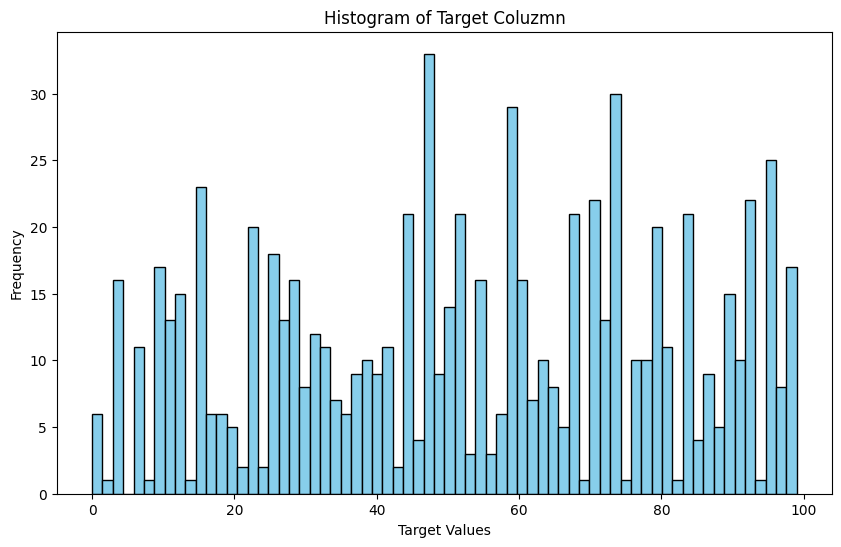

In [46]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [47]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,48018,15,84,15,19,0.203214,0.476119,0.295524,0.657062,False,True,False,True,False
1,48347,79,26,14,14,0.382591,0.802145,0.689604,0.843361,False,False,False,True,False
2,47972,12,68,68,69,0.746090,0.894188,0.391759,0.990091,False,False,False,True,False
3,46297,98,35,98,35,0.477041,0.475674,0.496640,0.726992,False,True,False,True,False
4,1017,1,1,1,1,0.972903,0.999967,0.996955,0.922359,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,19333,29,29,29,29,0.206156,0.699154,0.693349,0.954020,True,True,True,True,True
9996,43850,44,27,44,44,0.438487,0.470414,0.409671,0.970933,False,True,True,True,True
9997,19169,85,85,85,85,0.998196,0.999999,0.999653,0.999950,True,True,True,True,True
9998,32130,92,92,92,92,0.899796,0.963178,0.716453,0.839465,True,True,True,True,True


In [48]:
df_results_v[(df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,48018,15,84,15,19,0.203214,0.476119,0.295524,0.657062,False,True,False,True,False
1,48347,79,26,14,14,0.382591,0.802145,0.689604,0.843361,False,False,False,True,False
3,46297,98,35,98,35,0.477041,0.475674,0.496640,0.726992,False,True,False,True,False
7,9200,33,59,33,33,0.529394,0.445741,0.339279,0.615309,False,True,True,True,True
10,48644,55,73,67,67,0.338569,0.707345,0.450946,0.750466,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,11308,49,34,49,49,0.110406,0.766251,0.159979,0.897690,False,True,True,True,True
9986,3476,7,50,36,50,0.690994,0.686465,0.511392,0.707086,False,False,False,True,False
9987,48245,80,72,4,4,0.258859,0.441520,0.204487,0.700300,False,False,False,True,False
9998,32130,92,92,92,92,0.899796,0.963178,0.716453,0.839465,True,True,True,True,True


In [49]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])&(df_results_v['Decision']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
32,32186,95,95,95,95,0.678804,0.966531,0.799973,0.630906,True,True,True,False,True
39,41218,52,47,52,52,0.538217,0.999080,0.936297,0.610709,False,True,True,False,True
52,48736,15,15,15,15,0.223593,0.461863,0.278926,0.660499,True,True,True,False,True
126,29925,71,71,71,71,0.418093,0.756440,0.471157,0.511651,True,True,True,False,True
329,16658,52,47,52,52,0.884982,0.678623,0.536784,0.649505,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9531,39595,30,73,30,30,0.442804,0.953994,0.706534,0.630639,False,True,True,False,True
9591,8708,74,74,74,74,0.287091,0.516619,0.294626,0.583445,True,True,True,False,True
9718,32242,3,3,3,3,0.423594,0.676250,0.405896,0.535784,True,True,True,False,True
9737,757,93,73,93,93,0.229929,0.331179,0.345001,0.673978,False,True,True,False,True


In [50]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

72    84
80    66
55    64
93    62
11    60
      ..
70    12
8     11
53    11
94    10
69     9
Name: Target, Length: 100, dtype: int64

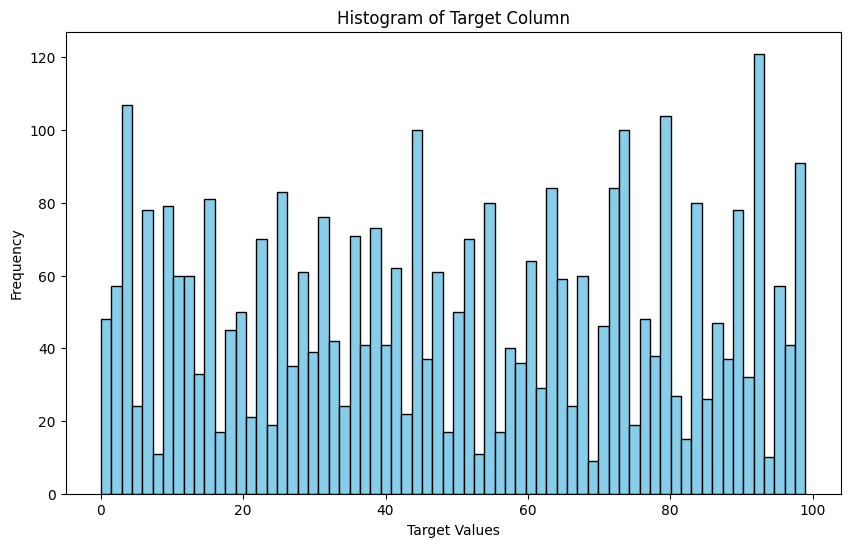

In [51]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [52]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_train_loss,total_train_accu,sum_F,sum_T


(0.2719586606889963, 0.937625, 3470, 36530)

In [53]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.4555130972862245, 0.6609, 1187, 8813)